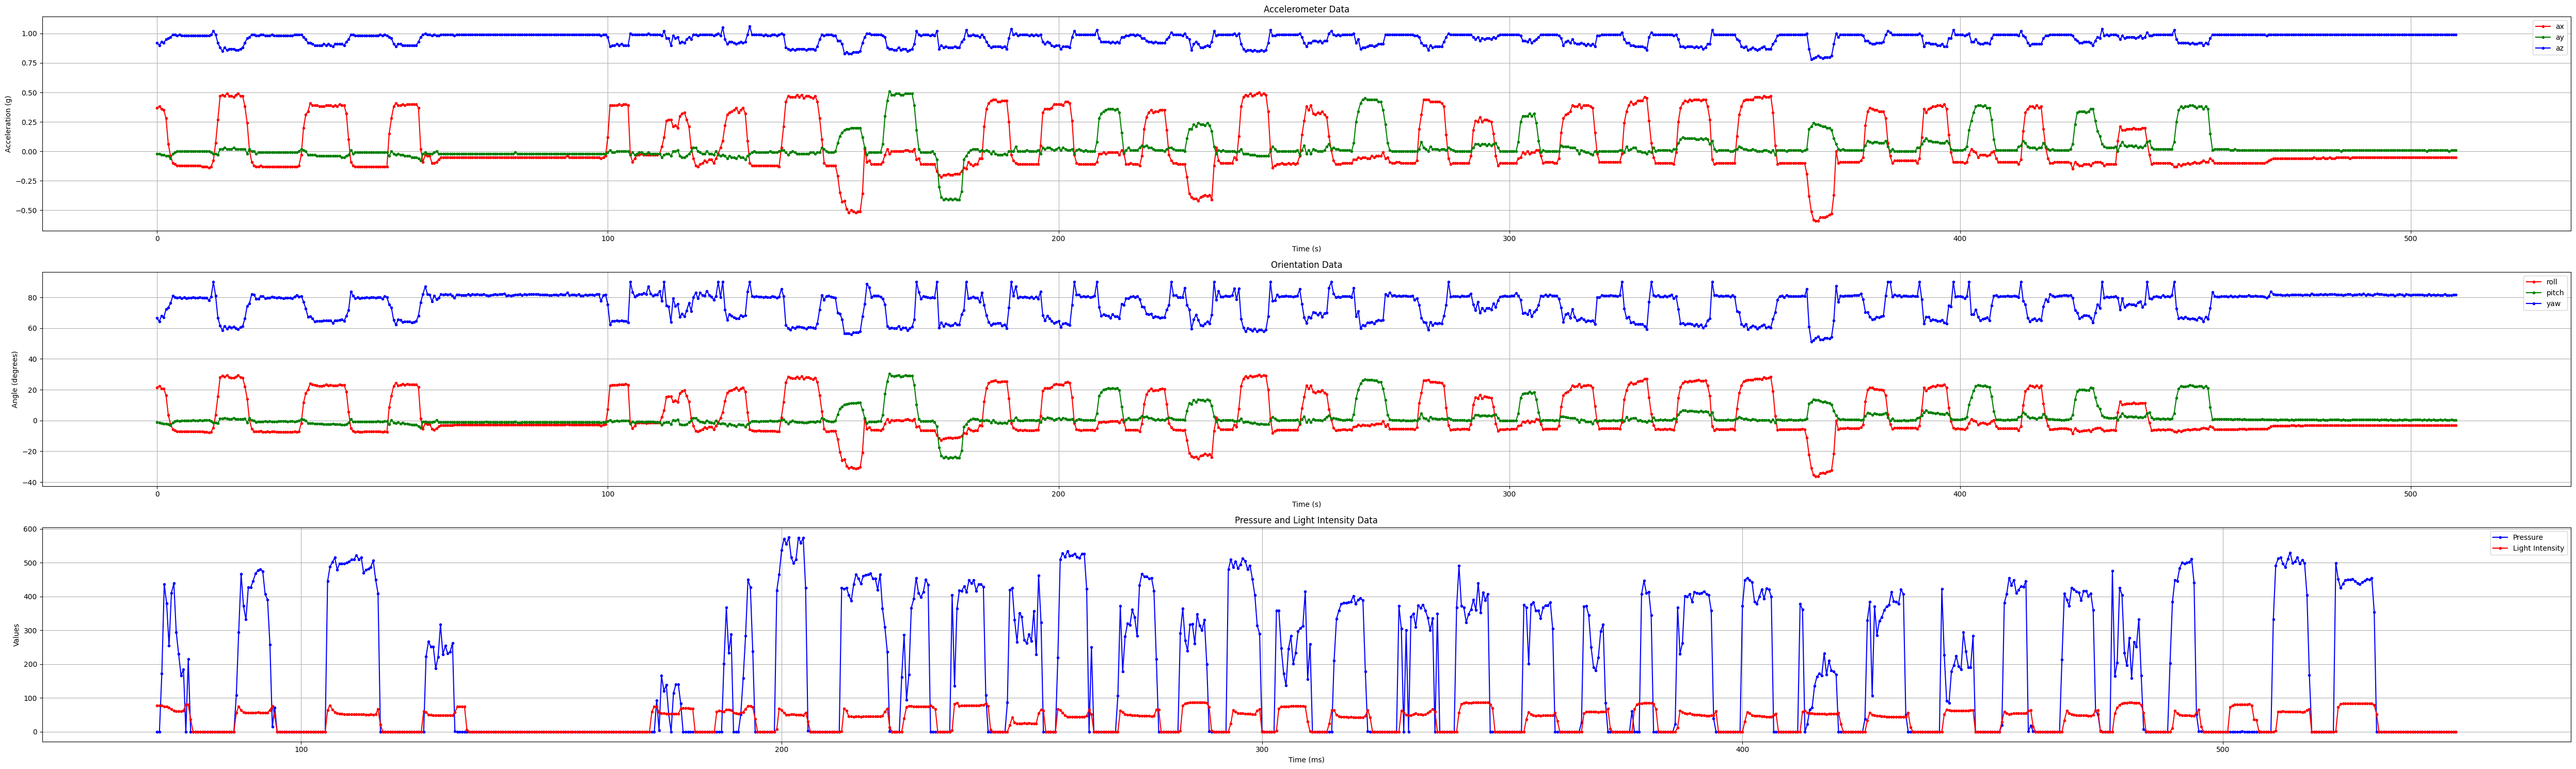

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Part 1: Plot IMU data
# Define file path for IMU data
imu_file_path = "data_IMU.txt"

# Read the IMU data
imu_df = pd.read_csv(imu_file_path, header=None, names=["ax", "ay", "az", "r", "p", "y"])
imu_df = imu_df[80:]
# Create a time column (assuming 0.5s per row)
imu_df["Time"] = [i * 0.5 for i in range(len(imu_df))]

# Part 2: Plot Pressure and Light data
# Define file path for pressure and light data
press_light_file_path = "data_press_light.txt"

# Read the pressure and light data as provided
press_light_df = pd.read_csv(press_light_file_path, delim_whitespace=True, header=None, 
                            names=["Time (ms)", "Pressure", "Light Intensity (lux)", "Unit"])
press_light_df = press_light_df[139:]
# Drop the unnecessary unit column
press_light_df = press_light_df.drop(columns=["Unit"])

# Convert time from milliseconds to seconds
press_light_df["Time (ms)"] = press_light_df["Time (ms)"] / 1000

# Create a figure with three subplots
plt.figure(figsize=(50, 15))

# Plot 1: Accelerometer data
plt.subplot(3, 1, 1)
plt.plot(imu_df["Time"], imu_df["ax"], marker='.', linestyle='-', color='r', label="ax")
plt.plot(imu_df["Time"], imu_df["ay"], marker='.', linestyle='-', color='g', label="ay")
plt.plot(imu_df["Time"], imu_df["az"], marker='.', linestyle='-', color='b', label="az")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Accelerometer Data")
plt.legend()
plt.grid(True)

# Plot 2: Orientation data
plt.subplot(3, 1, 2)
plt.plot(imu_df["Time"], imu_df["r"], marker='.', linestyle='-', color='r', label="roll")
plt.plot(imu_df["Time"], imu_df["p"], marker='.', linestyle='-', color='g', label="pitch")
plt.plot(imu_df["Time"], imu_df["y"], marker='.', linestyle='-', color='b', label="yaw")
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Orientation Data")
plt.legend()
plt.grid(True)

# Plot 3: Pressure and Light Intensity
plt.subplot(3, 1, 3)
plt.plot(press_light_df["Time (ms)"], press_light_df["Pressure"], marker='.', 
         linestyle='-', color='b', label="Pressure")
plt.plot(press_light_df["Time (ms)"], press_light_df["Light Intensity (lux)"], marker='.', 
         linestyle='-', color='r', label="Light Intensity")
plt.xlabel("Time (ms)")
plt.ylabel("Values")
plt.title("Pressure and Light Intensity Data")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

IMU data: 1021 rows, time range: 0 to 510000 ms
Pressure/Light data: 958 rows, time range: 0 to 478500 ms
Detected rest orientation: r=-6.99, p=-0.18, y=79.57
Estimated gravity components: ax=-0.095g, ay=0.000g, az=0.980g
Gravity magnitude: 0.985g (should be close to 1)
Found 108 potential tilt events
Found 433 potential pressure events
Found 482 potential light events
Found 34 pick-place events

Detected 34 pick-place events:
Pick-Place 1: 1.0s to 4.0s (duration: 3.0s)
Pick-Place 2: 12.0s to 21.5s (duration: 9.5s)
Pick-Place 3: 31.5s to 44.0s (duration: 12.5s)
Pick-Place 4: 50.5s to 60.0s (duration: 9.5s)
Pick-Place 5: 99.0s to 106.0s (duration: 7.0s)
Pick-Place 6: 107.0s to 119.5s (duration: 12.5s)
Pick-Place 7: 124.0s to 132.5s (duration: 8.5s)
Pick-Place 8: 138.0s to 149.0s (duration: 11.0s)
Pick-Place 9: 150.5s to 158.0s (duration: 7.5s)
Pick-Place 10: 160.5s to 169.5s (duration: 9.0s)
Pick-Place 11: 172.5s to 180.0s (duration: 7.5s)
Pick-Place 12: 182.5s to 190.5s (duration: 8.0s

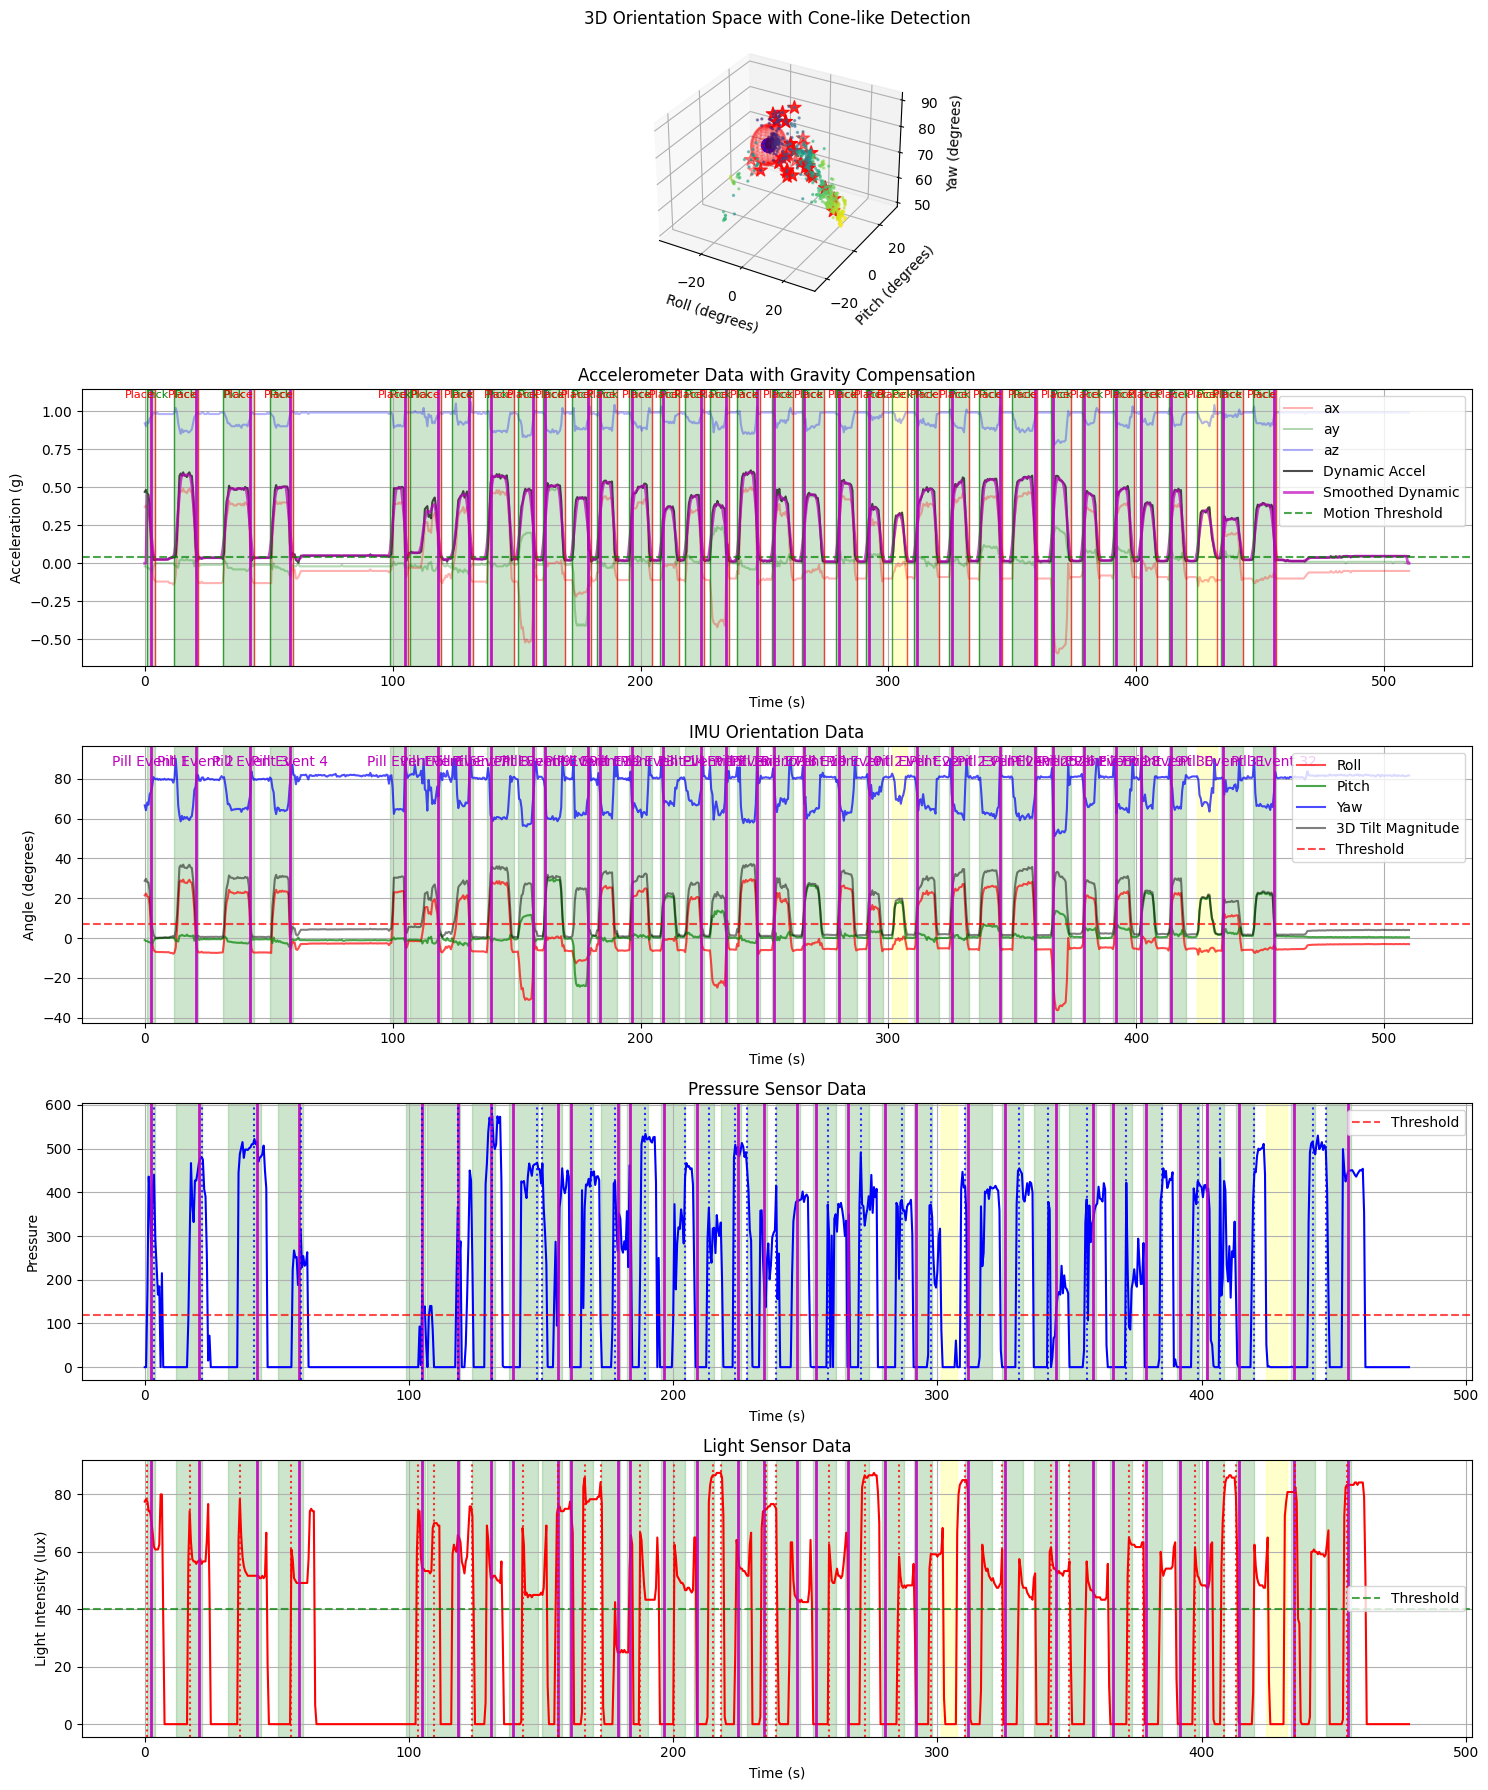

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import find_peaks

# 1. Load and preprocess IMU data
def load_imu_data(file_path):
    # Read all IMU data with correct column names
    full_imu_df = pd.read_csv(file_path, header=None, 
                           names=["ax", "ay", "az", "r", "p", "y"])
    
    # Skip the first 80 rows as specified
    imu_df = full_imu_df.iloc[80:].reset_index(drop=True)
    
    # Add time column (0.5s intervals) starting from 0
    imu_df["Time (ms)"] = [i * 500 for i in range(len(imu_df))]
    
    return imu_df

# 2. Load and preprocess pressure and light data
def load_pressure_light_data(file_path):
    # Read all pressure and light data
    full_press_light_df = pd.read_csv(file_path, delim_whitespace=True, header=None, 
                                names=["Time (ms)", "Pressure", "Light Intensity (lux)", "Unit"])
    
    # Skip the first 139 rows as specified
    press_light_df = full_press_light_df.iloc[139:].reset_index(drop=True)
    
    # Drop the unnecessary unit column
    press_light_df = press_light_df.drop(columns=["Unit"])
    
    # Adjust timestamps to start from 0
    first_timestamp = press_light_df["Time (ms)"].iloc[0]
    press_light_df["Time (ms)"] = press_light_df["Time (ms)"] - first_timestamp
    
    return press_light_df

# 3. Detect pick-and-place events using accelerometer data (with gravity compensation)
def detect_pick_place_events(imu_df, window_size=5, accel_threshold=0.05, min_event_duration=2000):
    """
    Detect when the pill container is picked up and placed down using accelerometer data,
    accounting for gravity.
    
    Args:
        imu_df: DataFrame with IMU data
        window_size: Window size for smoothing acceleration
        accel_threshold: Threshold for detecting significant acceleration changes
        min_event_duration: Minimum duration of a pick-place event in ms
    
    Returns:
        DataFrame with pick-place events (start and end times)
    """
    # The accelerometer data is typically normalized to g (9.8 m/s²)
    # When device is at rest, the gravity component results in |a| ≈ 1
    
    # Calculate the gravity vector components from initial resting position
    # We'll use a portion of the initial data where the device is likely at rest
    rest_samples = min(50, len(imu_df) // 10)  # Use first 50 samples or 10% of data
    
    if rest_samples > 0:
        rest_ax = imu_df['ax'].iloc[:rest_samples].median()
        rest_ay = imu_df['ay'].iloc[:rest_samples].median()
        rest_az = imu_df['az'].iloc[:rest_samples].median()
        print(f"Estimated gravity components: ax={rest_ax:.3f}g, ay={rest_ay:.3f}g, az={rest_az:.3f}g")
        
        # Verify that the gravity magnitude is approximately 1g
        gravity_mag = np.sqrt(rest_ax**2 + rest_ay**2 + rest_az**2)
        print(f"Gravity magnitude: {gravity_mag:.3f}g (should be close to 1)")
        
        # Normalize gravity components if needed
        if abs(gravity_mag - 1.0) > 0.1:  # If not close to 1g
            correction = 1.0 / gravity_mag
            rest_ax *= correction
            rest_ay *= correction
            rest_az *= correction
            print(f"Normalized gravity components: ax={rest_ax:.3f}g, ay={rest_ay:.3f}g, az={rest_az:.3f}g")
    else:
        # Fallback if we don't have enough data
        rest_ax, rest_ay, rest_az = 0, 0, 1
    
    # Remove gravity component from each acceleration reading to get dynamic acceleration
    imu_df['ax_dynamic'] = imu_df['ax'] - rest_ax
    imu_df['ay_dynamic'] = imu_df['ay'] - rest_ay
    imu_df['az_dynamic'] = imu_df['az'] - rest_az
    
    # Calculate dynamic acceleration magnitude (without gravity)
    imu_df['accel_dynamic'] = np.sqrt(
        imu_df['ax_dynamic']**2 + 
        imu_df['ay_dynamic']**2 + 
        imu_df['az_dynamic']**2
    )
    
    # Apply rolling window to smooth the signal
    imu_df['accel_smooth'] = imu_df['accel_dynamic'].rolling(window=window_size, center=True).mean()
    imu_df['accel_smooth'] = imu_df['accel_smooth'].fillna(0)
    
    # Detect state changes (in motion vs. static)
    imu_df['in_motion'] = imu_df['accel_smooth'] > accel_threshold
    
    # Find state change points (0->1 = pick up, 1->0 = place down)
    imu_df['state_change'] = imu_df['in_motion'].astype(int).diff().fillna(0)
    
    # Get pick up events (state_change = 1)
    pick_events = imu_df[imu_df['state_change'] == 1]['Time (ms)'].tolist()
    
    # Get place down events (state_change = -1)
    place_events = imu_df[imu_df['state_change'] == -1]['Time (ms)'].tolist()
    
    # Ensure we have matching picks and places
    # If we start with the device in motion, the first event will be a place
    if place_events and (not pick_events or place_events[0] < pick_events[0]):
        place_events = place_events[1:]
    
    # If we end with the device in motion, the last event will be a pick
    if pick_events and (not place_events or pick_events[-1] > place_events[-1]):
        pick_events = pick_events[:-1]
    
    # Create pairs of pick and place events
    pick_place_events = []
    for pick_time, place_time in zip(pick_events, place_events):
        duration = place_time - pick_time
        
        # Only count events with sufficient duration
        if duration >= min_event_duration:
            pick_place_events.append({
                'pick_time': pick_time,
                'place_time': place_time,
                'duration': duration
            })
    
    return pd.DataFrame(pick_place_events)

# 4. Detect events from sensors with improved detection using pick-place windows
def detect_events(imu_df, press_light_df, pick_place_events, 
                 tilt_threshold=8, pressure_threshold=150, light_threshold=40,
                 rest_r=0, rest_p=0, rest_y=80):
    
    # Calculate 3D angular distance from rest position (cone-like detection)
    r_weight, p_weight, y_weight = 1.0, 1.0, 0.3  # Adjust these weights as needed
    
    imu_df['r_diff'] = r_weight * (imu_df['r'] - rest_r)
    imu_df['p_diff'] = p_weight * (imu_df['p'] - rest_p)
    imu_df['y_diff'] = y_weight * (imu_df['y'] - rest_y)
    
    # Calculate 3D angular distance (cone radius)
    imu_df['tilt_magnitude'] = np.sqrt(
        imu_df['r_diff']**2 + 
        imu_df['p_diff']**2 + 
        imu_df['y_diff']**2
    )
    
    # Calculate rate of change in 3D tilt (derivative)
    imu_df['tilt_change'] = imu_df['tilt_magnitude'].diff().abs()
    
    # Find tilt events where 3D change exceeds threshold
    tilt_events = imu_df[imu_df['tilt_change'] > tilt_threshold][['Time (ms)', 'tilt_change', 'r', 'p', 'y']]
    
    # Detect pressure events
    pressure_events = press_light_df[press_light_df['Pressure'] > pressure_threshold][['Time (ms)', 'Pressure']]
    
    # Detect light events
    light_events = press_light_df[press_light_df['Light Intensity (lux)'] > light_threshold][['Time (ms)', 'Light Intensity (lux)']]
    
    # For debugging
    print(f"Found {len(tilt_events)} potential tilt events")
    print(f"Found {len(pressure_events)} potential pressure events")
    print(f"Found {len(light_events)} potential light events")
    print(f"Found {len(pick_place_events)} pick-place events")
    
    # Identify pill retrieval events within each pick-place window
    pill_retrieval_events = []
    
    for _, pp_event in pick_place_events.iterrows():
        pick_time = pp_event['pick_time']
        place_time = pp_event['place_time']
        
        # Find tilt events in this pick-place window
        window_tilt_events = tilt_events[
            (tilt_events['Time (ms)'] >= pick_time) & 
            (tilt_events['Time (ms)'] <= place_time)
        ]
        
        # Find pressure events in this pick-place window
        window_pressure_events = pressure_events[
            (pressure_events['Time (ms)'] >= pick_time) & 
            (pressure_events['Time (ms)'] <= place_time)
        ]
        
        # Find light events in this pick-place window
        window_light_events = light_events[
            (light_events['Time (ms)'] >= pick_time) & 
            (light_events['Time (ms)'] <= place_time)
        ]
        
        # If all three sensor events occurred in this window, it's a pill retrieval
        if (not window_tilt_events.empty and 
            not window_pressure_events.empty and 
            not window_light_events.empty):
            
            # Take the strongest tilt event as our reference
            max_tilt_idx = window_tilt_events['tilt_change'].idxmax()
            main_tilt_event = window_tilt_events.loc[max_tilt_idx]
            
            # Take the max pressure event
            max_pressure_idx = window_pressure_events['Pressure'].idxmax()
            main_pressure_event = window_pressure_events.loc[max_pressure_idx]
            
            # Take the max light event
            max_light_idx = window_light_events['Light Intensity (lux)'].idxmax()
            main_light_event = window_light_events.loc[max_light_idx]
            
            # Create a single event for this pick-place window
            pill_retrieval_events.append({
                'Time (ms)': main_tilt_event['Time (ms)'],
                'Tilt': main_tilt_event['tilt_change'],
                'r': main_tilt_event['r'],
                'p': main_tilt_event['p'],
                'y': main_tilt_event['y'],
                'Pressure': main_pressure_event['Pressure'],
                'Light': main_light_event['Light Intensity (lux)'],
                'Pressure_time': main_pressure_event['Time (ms)'],
                'Light_time': main_light_event['Time (ms)'],
                'pick_time': pick_time,
                'place_time': place_time
            })
    
    return pd.DataFrame(pill_retrieval_events), imu_df

# 5. Main function to detect pill retrievals
def detect_pill_retrievals(imu_file, press_light_file):
    # Load data with proper offsets
    imu_df = load_imu_data(imu_file)
    press_light_df = load_pressure_light_data(press_light_file)
    
    # Print data summary after offset adjustments
    print(f"IMU data: {len(imu_df)} rows, time range: {imu_df['Time (ms)'].min()} to {imu_df['Time (ms)'].max()} ms")
    print(f"Pressure/Light data: {len(press_light_df)} rows, time range: {press_light_df['Time (ms)'].min()} to {press_light_df['Time (ms)'].max()} ms")
    
    # Find typical rest position by analyzing the stable parts of the data
    rest_r = imu_df['r'].iloc[:20].median()
    rest_p = imu_df['p'].iloc[:20].median()
    rest_y = imu_df['y'].iloc[:20].median()
    
    print(f"Detected rest orientation: r={rest_r:.2f}, p={rest_p:.2f}, y={rest_y:.2f}")
    
    # Detect pick-place events with gravity compensation
    pick_place_events = detect_pick_place_events(
        imu_df, 
        window_size=5,               # Smoothing window size
        accel_threshold=0.06,        # Threshold for detecting motion (after gravity removal)
        min_event_duration=1500      # Minimum duration of pick-place event
    )
    
    # Detect events within pick-place windows
    pill_events, updated_imu_df = detect_events(
        imu_df, 
        press_light_df, 
        pick_place_events,
        tilt_threshold=7,            # Sensitivity for 3D orientation changes
        pressure_threshold=120,      # Minimum pressure to register a press
        light_threshold=40,          # Minimum light intensity
        rest_r=rest_r,               # Rest position roll
        rest_p=rest_p,               # Rest position pitch
        rest_y=rest_y                # Rest position yaw
    )
    
    # Create a figure with 5 subplots (1 3D + 4 regular)
    fig = plt.figure(figsize=(15, 18))
    
    # 3D plot to visualize orientation
    ax3d = fig.add_subplot(5, 1, 1, projection='3d')
    ax3d.scatter(updated_imu_df['r'], updated_imu_df['p'], updated_imu_df['y'], 
                c=updated_imu_df['tilt_magnitude'], cmap='viridis', s=2, alpha=0.5)
    
    # Mark detected events in 3D
    if not pill_events.empty:
        ax3d.scatter(pill_events['r'], pill_events['p'], pill_events['y'], 
                   color='red', s=100, marker='*')
    
    threshold = 7  # Same as tilt_threshold
    u = np.linspace(0, 2 * np.pi, 20)
    v = np.linspace(0, np.pi, 20)
    r_sphere = threshold * np.outer(np.cos(u), np.sin(v)) + rest_r
    p_sphere = threshold * np.outer(np.sin(u), np.sin(v)) + rest_p
    y_sphere = threshold * np.outer(np.ones(np.size(u)), np.cos(v)) + rest_y
    ax3d.plot_wireframe(r_sphere, p_sphere, y_sphere, color='r', alpha=0.2)
    
    # Mark rest position
    ax3d.scatter([rest_r], [rest_p], [rest_y], color='blue', s=100, marker='o')
    
    ax3d.set_xlabel('Roll (degrees)')
    ax3d.set_ylabel('Pitch (degrees)')
    ax3d.set_zlabel('Yaw (degrees)')
    ax3d.set_title('3D Orientation Space with Cone-like Detection')
    
    # Regular 2D plots
    axes = [fig.add_subplot(5, 1, i+2) for i in range(4)]
    
    # Plot 1: Accelerometer Data for Pick-Place Detection (with gravity compensation)
    axes[0].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["ax"], 'r-', 
                label="ax", alpha=0.3)
    axes[0].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["ay"], 'g-', 
                label="ay", alpha=0.3)
    axes[0].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["az"], 'b-', 
                label="az", alpha=0.3)
    
    if 'accel_dynamic' in updated_imu_df.columns:
        axes[0].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["accel_dynamic"], 'k-', 
                    label="Dynamic Accel", alpha=0.7)
    if 'accel_smooth' in updated_imu_df.columns:
        axes[0].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["accel_smooth"], 'm-', 
                    label="Smoothed Dynamic", alpha=0.7, linewidth=2)
        axes[0].axhline(y=0.04, color='g', linestyle='--', alpha=0.7, label="Motion Threshold")
    
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Acceleration (g)")
    axes[0].set_title("Accelerometer Data with Gravity Compensation")
    axes[0].grid(True)
    axes[0].legend()
    
    # Plot 2: IMU Tilt Data
    axes[1].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["r"], 'r-', label="Roll", alpha=0.7)
    axes[1].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["p"], 'g-', label="Pitch", alpha=0.7)
    axes[1].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["y"], 'b-', label="Yaw", alpha=0.7)
    if 'tilt_magnitude' in updated_imu_df.columns:
        axes[1].plot(updated_imu_df["Time (ms)"]/1000, updated_imu_df["tilt_magnitude"], 'k-', 
                    label="3D Tilt Magnitude", alpha=0.5)
    axes[1].axhline(y=threshold, color='r', linestyle='--', alpha=0.7, label="Threshold")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Angle (degrees)")
    axes[1].set_title("IMU Orientation Data")
    axes[1].grid(True)
    axes[1].legend()
    
    # Plot 3: Pressure Data
    axes[2].plot(press_light_df["Time (ms)"]/1000, press_light_df["Pressure"], 'b-')
    axes[2].axhline(y=120, color='r', linestyle='--', alpha=0.7, label="Threshold")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Pressure")
    axes[2].set_title("Pressure Sensor Data")
    axes[2].grid(True)
    axes[2].legend()
    
    # Plot 4: Light Data
    axes[3].plot(press_light_df["Time (ms)"]/1000, press_light_df["Light Intensity (lux)"], 'r-')
    axes[3].axhline(y=40, color='g', linestyle='--', alpha=0.7, label="Threshold")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("Light Intensity (lux)")
    axes[3].set_title("Light Sensor Data")
    axes[3].grid(True)
    axes[3].legend()
    
    # Shade pick-place events on all 2D plots
    for _, pp_event in pick_place_events.iterrows():
        pick_time = pp_event['pick_time'] / 1000   # Convert to seconds
        place_time = pp_event['place_time'] / 1000  # Convert to seconds
        
        # Check if this pick-place event contains a pill event
        has_pill_event = False
        if not pill_events.empty:
            for _, pill_event in pill_events.iterrows():
                event_time = pill_event['Time (ms)'] / 1000
                if pick_time <= event_time <= place_time:
                    has_pill_event = True
                    break
        
        # Color pick-place windows according to whether they contain pill events
        color = 'green' if has_pill_event else 'yellow'
        
        for i, ax in enumerate(axes):
            y_min, y_max = ax.get_ylim()
            height = y_max - y_min
            
            # Add shaded rectangle for the pick-place window
            rect = Rectangle((pick_time, y_min), 
                          width=(place_time - pick_time), 
                          height=height,
                          color=color, alpha=0.2)
            ax.add_patch(rect)
            
            # Add vertical lines for pick-up and place-down
            if i == 0:  # Only add labels to the first plot
                ax.axvline(x=pick_time, color='green', linestyle='-', alpha=0.7, linewidth=1)
                ax.axvline(x=place_time, color='red', linestyle='-', alpha=0.7, linewidth=1)
                ax.text(pick_time, y_max*0.95, "Pick", fontsize=8, color='green', ha='left')
                ax.text(place_time, y_max*0.95, "Place", fontsize=8, color='red', ha='right')
    
    # Mark pill retrieval events with vertical lines on all plots
    if not pill_events.empty:
        for idx, event in pill_events.iterrows():
            event_time = event['Time (ms)'] / 1000  # Convert to seconds
            
            for i, ax in enumerate(axes):
                # Add vertical lines for the actual event times
                ax.axvline(x=event_time, color='m', linestyle='-', alpha=0.9, linewidth=2)
                
                # Add event label to the tilt plot (plot 1)
                if i == 1:
                    y_min, y_max = ax.get_ylim()
                    ax.text(event_time, y_max*0.9, f"Pill Event {idx+1}", 
                           fontsize=10, color='m', ha='center')
                
                # Add vertical dashed lines for pressure and light event times if available
                if i == 2 and 'Pressure_time' in event:  # Pressure plot
                    press_time = event['Pressure_time'] / 1000
                    ax.axvline(x=press_time, color='blue', linestyle=':', alpha=0.8)
                    
                if i == 3 and 'Light_time' in event:  # Light plot
                    light_time = event['Light_time'] / 1000
                    ax.axvline(x=light_time, color='red', linestyle=':', alpha=0.8)
    
    plt.tight_layout()
    
    return pill_events, updated_imu_df, pick_place_events

# Run the algorithm
imu_file = "data_IMU.txt"
press_light_file = "data_press_light.txt"
pill_events, updated_imu_df, pick_place_events = detect_pill_retrievals(imu_file, press_light_file)

# Print detected pick-place events
print(f"\nDetected {len(pick_place_events)} pick-place events:")
for index, event in pick_place_events.iterrows():
    pick_time = event['pick_time'] / 1000
    place_time = event['place_time'] / 1000
    duration = event['duration'] / 1000
    print(f"Pick-Place {index+1}: {pick_time:.1f}s to {place_time:.1f}s (duration: {duration:.1f}s)")

# Print detected pill retrieval events
print(f"\nDetected {len(pill_events)} pill retrieval events:")
if not pill_events.empty:
    for index, event in pill_events.iterrows():
        timestamp = event['Time (ms)']
        seconds = timestamp / 1000
        minutes = seconds // 60
        seconds = seconds % 60
        
        pick_time = event['pick_time'] / 1000
        place_time = event['place_time'] / 1000
        
        print(f"Pill Event {index+1}: Time {int(minutes)}m {seconds:.1f}s")
        print(f"  - Within Pick-Place window: {pick_time:.1f}s to {place_time:.1f}s")
        print(f"  - 3D Tilt: {event['Tilt']:.2f} at {seconds:.1f}s")
        print(f"  - Orientation: Roll={event['r']:.2f}°, Pitch={event['p']:.2f}°, Yaw={event['y']:.2f}°")
        print(f"  - Pressure: {event['Pressure']:.0f} at {event['Pressure_time']/1000:.1f}s")
        print(f"  - Light: {event['Light']:.2f} lux at {event['Light_time']/1000:.1f}s")
else:
    print("No pill retrieval events detected with current thresholds.")